In [2]:
#import of method and libraries
#data manipulation and mathematics
import pandas as pd
import numpy as np
#graphic visualization
import matplotlib.cm as cm
import matplotlib.pyplot as plt
#file managing and export
import joblib
import json
#tools to train the models
from sklearn.model_selection import KFold, cross_val_score, train_test_split, cross_validate
#different models to train
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (GradientBoostingRegressor,HistGradientBoostingRegressor, RandomForestRegressor)
#tools to scale the data and make polynomial features
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
#tools to measure precision of prediction
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pd.set_option("display.width", 10000)
pd.set_option("display.max_columns", 14)

In [3]:
#upload of the Rotate sheet of the odf file
datafile = pd.read_excel("test.ods",engine="odf", sheet_name='Rotate')
#column of the effective movement
eff_move=[1,2,3,4,5,6,7,8,9,10]
#data cleaning
datafile[eff_move]=datafile[eff_move].apply(pd.to_numeric, errors="coerce")
#calculation of mean std and th_err
datafile["mean"]=datafile[eff_move].mean(axis=1)
datafile["std"]=datafile[eff_move].std(axis=1)

datafile["th_err"]= datafile["mean"]-datafile["th_move"]

datafile = datafile.dropna(subset=["time", "power","th_move","th_err"] + eff_move)
#exctraction of features and target
x_orig=datafile[["time", "power"]].values
y=datafile["th_err"].values
print("dataset preview")
print(datafile[["time","power","th_move","mean","th_err"]].head())

dataset preview
    time  power  th_move  mean  th_err
1  200.0   0.05     2.88   4.0    1.12
2  300.0   0.05     4.32   6.0    1.68
3  400.0   0.05     5.76   8.0    2.24
4  500.0   0.05     7.20   8.0    0.80
5  600.0   0.05     8.64  10.0    1.36


In [4]:
#x: indipendent variables
x=datafile[["time", "power"]].values
#y_err:main target
y_err=datafile["th_err"].values
#y_std: secondary target
y_std=datafile["std"].values

#variable for choosing the best degree
best_degree=2
best_r2=-np.inf

#K fold Cross-validation with 5 split
kf= KFold(n_splits=5,shuffle=True, random_state=43)

#assesment of the best degree
for degree in [2,3,4,5,6]:
    #StandardScaler: normalizing data
    #PolynomialFeatures: create non linear combination
    #LinearRegression: calculate final weight
    model=make_pipeline(StandardScaler(), PolynomialFeatures(degree=degree), LinearRegression())

    #assesment of the stability of the error model
    scores = cross_val_score(model, x, y_err,cv=kf,scoring="r2")
    mean_r2=np.mean(scores)

    print(f"degree{degree} -> mean R2(cross_validation):{mean_r2:.4f}")

    if mean_r2 >best_r2:
        best_r2=mean_r2
        best_degree=degree

print(f"\nbest degree ->{best_degree}")

degree2 -> mean R2(cross_validation):0.8678
degree3 -> mean R2(cross_validation):0.8872
degree4 -> mean R2(cross_validation):0.8385
degree5 -> mean R2(cross_validation):0.8933
degree6 -> mean R2(cross_validation):0.8316

best degree ->5


In [5]:
#training of error model and std model
#training error model
model_err=make_pipeline(StandardScaler(),PolynomialFeatures(degree=best_degree),LinearRegression())
model_err.fit(x, y_err)
#training std model
model_std=make_pipeline(StandardScaler(),PolynomialFeatures(degree=best_degree),LinearRegression())
model_std.fit(x, y_std)

#metric calculation
y_err_pred=model_err.predict(x)
y_std_pred=model_std.predict(x)

print(f"\n error metrics")
#error metrics
print(f"R2: {r2_score(y_err,y_err_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_err,y_err_pred):.4f} m")
print(f"RMSE: {np.sqrt(mean_squared_error(y_err,y_err_pred)):.4f} m")

print(f"\n std metrics")
#std metrics
print(f"R2: {r2_score(y_std,y_std_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_std,y_std_pred):.4f} m")


 error metrics
R2: 0.9779
MAE: 0.2263 m
RMSE: 0.3033 m

 std metrics
R2: 0.5651
MAE: 0.0728 m


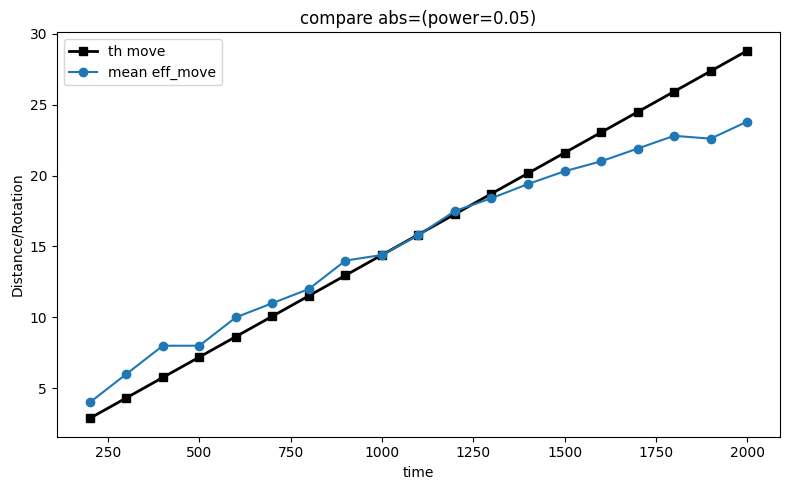

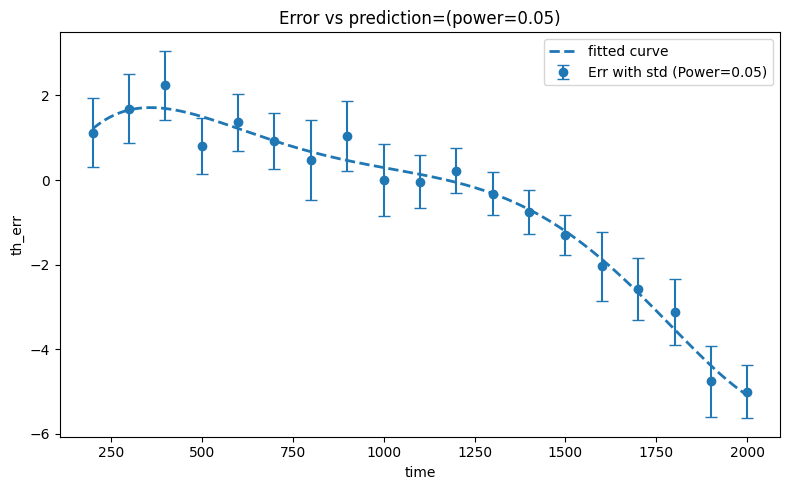

In [6]:
#Visualization of the graph
target_power=datafile["power"].iloc[0]
subset=datafile[datafile["power"]==target_power].sort_values("time")

#trajectory comparison with error bars
fig1, ax1=plt.subplots(figsize=(8,5))
# th line
ax1.plot(subset["time"], subset["th_move"], color="black", linewidth=2, marker="s",label = "th move")
# eff line with error bar
ax1.plot(subset["time"],subset["mean"],"o-" ,color="tab:blue", linewidth=1.5, label="mean eff_move")

ax1.set_xlabel("time")
ax1.set_ylabel("Distance/Rotation")
ax1.set_title(f"compare abs=(power={target_power})")
ax1.legend()

plt.tight_layout()
plt.show()

#fitted polinomial curve
fig2, ax2=plt.subplots(figsize=(8,5))
timerange=np.linspace(subset["time"].min(), subset["time"].max(), 200)
#preparation of the input matrix
x_curve=np.column_stack([timerange, np.full_like(timerange, target_power)])
#prediction of the curve
y_curve=model_err.predict(x_curve)
#visualisation of the curve
ax2.plot(timerange,y_curve,color="tab:blue", linewidth=2, linestyle="--", label="fitted curve")
#adding the error bar to the data
ax2.errorbar(subset["time"],subset["th_err"], yerr=subset["std"],fmt="o", capsize=4, elinewidth=1.5, color="tab:blue", label=f"Err with std (Power={target_power})")

ax2.set_xlabel("time")
ax2.set_ylabel("th_err")
ax2.set_title(f"Error vs prediction=(power={target_power})")
ax2.legend()
plt.tight_layout()
plt.show()

In [18]:
#calulation of metrics to be sure that i chose the right model
pd.set_option("display.width", 10000)
pd.set_option("display.max_columns", 14)

datafile = pd.read_excel("test.ods",engine="odf", sheet_name='Rotate')
eff_move=[1,2,3,4,5,6,7,8,9,10]

datafile[eff_move]=datafile[eff_move].apply(pd.to_numeric, errors="coerce")


datafile["th_err"]= datafile[eff_move].mean(axis=1)-datafile["th_move"]
datafile = datafile.dropna(subset=["time", "power","th_err"])

x_orig=datafile[["time", "power"]].values
y=datafile["th_err"].values

kf=KFold(n_splits=5,shuffle=True, random_state=43)

LR = LinearRegression()
HGBR=HistGradientBoostingRegressor(random_state=43)
GBR=GradientBoostingRegressor(random_state=43)
RFR=RandomForestRegressor(n_jobs=-1,random_state=43)

bestr2=-9999
bestmodel=None
best_mae=0
best_rmse=0

summary_list=[]

scoring = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error'}

#compare of the different model
for model in [LR,GBR,HGBR,RFR]:
    scores= cross_validate(model,x_orig,y,cv=kf,scoring=scoring)
    mean_r2= np.mean(scores['test_r2'])
    mean_mae= -np.mean(scores['test_mae'])
    mean_rmse= -np.mean(scores['test_rmse'])
    
    model_name=model.__class__.__name__
    summary_list.append({"Model": model_name, "R2": mean_r2,"MAE":mean_mae, "RMSE":mean_rmse})

    if mean_r2>bestr2:
        bestr2 = mean_r2
        bestmodel= model_name
        best_mae=mean_mae
        best_rmse=mean_rmse

df_summary=pd.DataFrame(summary_list).sort_values(by="R2",ascending=False)
print("Compare of all model")
print(df_summary.to_string(index=False))
print("\n")
print("best model: ", bestmodel)
print("R2: ", bestr2)
print("MAE: ", best_mae)
print("RMSE: ", best_rmse)

Compare of all model
                        Model        R2      MAE     RMSE
        RandomForestRegressor  0.818577 0.470637 0.559427
    GradientBoostingRegressor  0.629558 0.610691 0.684718
             LinearRegression  0.409453 0.721341 0.926512
HistGradientBoostingRegressor -0.592238 1.727983 1.998648


best model:  RandomForestRegressor
R2:  0.8185771999262237
MAE:  0.4706366666666666
RMSE:  0.5594271785529702


In [23]:
#this part is needed to export the result of the model


scaler= model_err.named_steps['standardscaler']
poly=model_err.named_steps['polynomialfeatures']
lr=model_err.named_steps['linearregression']
joblib.dump(model_err,"model_err_rotate_pipeline.joblib")

#EXTRACT THE MATHEMATICAL PARAMETER FOR KOTLIN
intercept=float(lr.intercept_)
coefficients=lr.coef_.tolist()
powers= poly.powers_.tolist()

scaler_mean=scaler.mean_.tolist()
scaler_scale=scaler.scale_.tolist()

export_data={"model_type": "PolynomialRegression_Scaled", "degree": int(poly.degree), "features":["time","power"],"scaler_mean": scaler_mean,"scaler_scale":scaler_scale,"intercept":intercept,
             "coefficients":coefficients, "powers": powers}

#EXPORT TO JSON FILE

json_filename="model_coefficient_rotate.json"
#write the parameters dictionary into a json file with 4 space indentation
with open(json_filename,"w") as f:
    json.dump(export_data, f, indent=4)

print(f"file exported with success in json: '{json_filename}'\n")

print("\n PRE VIEW OF JSON FILE STRUCTURE")
print(json.dumps(export_data, indent=4))

print("\n MATH EQUATION")

#initialize the equation term list starting with the formatted intercept
terms=[f"{intercept:.6f}"]

#iterate simultaneously through each coefficient and its corresponding exponent pair
for coef, p in zip(coefficients,powers):
    #ignore near zero coefficients for cleaner representation
    if abs(coef)> 1e-8:
        t_exp, p_exp=p[0],p[1]

        #format the numerical coefficient with its sign and 6 decimal places 
        term_str=f"{coef:+.6f}"

        #append 'time' feature string if its exponent is greater than 0
        if t_exp==1:
            term_str +=" * t_sc"
        elif t_exp >1:
            term_str +=f" * t_sc^{t_exp}"

        #append 'power' feature string if its exponent is greater than 0
        if p_exp==1:
            term_str +=" * p_sc"
        elif p_exp>1:
            term_str +=f" * p_sc^{p_exp}"

        terms.append(term_str)
#join all equation terms into a single formatted string
equation="th_err=" + " ".join(terms)

#print the readable algebraic formula
print(equation)

file exported with success in json: 'model_coefficient_rotate.json'


 PRE VIEW OF JSON FILE STRUCTURE
{
    "model_type": "PolynomialRegression_Scaled",
    "degree": 5,
    "features": [
        "time",
        "power"
    ],
    "scaler_mean": [
        1100.0,
        0.05000000000000001
    ],
    "scaler_scale": [
        547.7225575051662,
        1.0
    ],
    "intercept": 0.13441109166778809,
    "coefficients": [
        -3.3306690738754696e-16,
        -0.919849751969711,
        2.220446049250313e-16,
        -0.45835500312044847,
        8.838387724523668e-18,
        0.0,
        -1.1750927377354423,
        3.1804767369778624e-18,
        -4.4289154541391007e-35,
        0.0,
        -0.11460767997650531,
        8.153843834398116e-18,
        -2.2068990641734443e-35,
        3.073177444564632e-52,
        0.0,
        0.29859689835723807,
        7.952505319299232e-19,
        -5.657865727591663e-35,
        1.5313438462931693e-52,
        -2.1324452235714722e-69,
    